# Iterative Radiomics-Guided Region Growing Algorithm

## Objective

Implement an iterative region growing algorithm using voxel-based PyRadiomics features on SPECT tumor images.

## Algorithm Overview

1. **Load SPECT DICOM Study**: Import full 3D DICOM series using SimpleITK
2. **Extract & Display Coronal Slice**: Select a specific coronal plane for analysis
3. **Define Working ROI**: Crop the coronal slice to the region of interest
4. **Create Initial Lesion Mask**: Apply intensity thresholding to identify potential lesion
5. **Compute Reference Radiomic Map**: Extract voxel-based Median map inside initial ROI (ROI0)
6. **Establish Statistical Limits**: Use ROI0 distribution as fixed reference (mean ± k*std)
7. **Iterative Region Growing**:
   - Dilate current ROI to generate candidate voxels (corona)
   - Compute voxel-based Median for dilated region
   - Classify each voxel: accept if within statistical bounds
   - Update ROI with accepted voxels
   - Repeat for N iterations
8. **Generate Results & Visualizations**

## Key Implementation Details

- **Radiomic Feature**: `firstorder.Median` (voxel-based)
- **Reference Distribution**: Fixed throughout all iterations
- **PyRadiomics Coordinate Handling**: Automatic reconstruction from bounding-box to full-image coordinates
- **Configurable Parameters**: Threshold percentage, k-value, number of iterations

In [67]:
# ==============================================================================
# 1. IMPORTS & SETUP
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import SimpleITK as sitk
from pathlib import Path
from scipy.ndimage import binary_dilation
from radiomics import featureextractor
import matplotlib.patches as patches

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Variable parameters

### 1. **Threshold**
### 2. **k_value**
### 3. **Caracteristica radiomica**

In [68]:
# ==============================================================================
# 2. CONFIGURATION & PARAMETERS
# ============================================================================== 

# Data paths
DATA_DIR = Path("PSMAB37")
SPECT_DIR = DATA_DIR / "SPECT"

# Imaging parameters
START_SLICE = 129              # First coronal slice to process
END_SLICE = 140                # Last coronal slice to process (inclusive)
SLICE_RANGE = range(START_SLICE, END_SLICE + 1)
ROI_CROP = (220, 140)          # (row_start, col_start) - fixed for all slices

# Thresholding parameters
THRESHOLD_PERCENTILE = 0.65    # Initial mask: percentage of max intensity

# Radiomic parameters
FEATURE_CLASS = "firstorder"   # Only firstorder features are supported in current pipeline
FEATURE_NAME = "Median"        # Example values: Median, Mean, Entropy, Energy
FEATURE_KEY = f"original_{FEATURE_CLASS}_{FEATURE_NAME}"

K_VALUE = 10                   # Acceptance limits: mean ± k*std
NUM_ITERATIONS = 15            # Number of region-growing iterations

print(f"✓ Configuration loaded")
print(f"  - SPECT directory: {SPECT_DIR}")
print(f"  - Slice range: {START_SLICE} to {END_SLICE} ({len(SLICE_RANGE)} slices)")
print(f"  - ROI crop offset (fixed): {ROI_CROP}")
print(f"  - Radiomic feature: {FEATURE_CLASS}.{FEATURE_NAME}")
print(f"  - K-value (acceptance bounds): {K_VALUE}")
print(f"  - Iterations per slice: {NUM_ITERATIONS}")

✓ Configuration loaded
  - SPECT directory: PSMAB37\SPECT
  - Slice range: 129 to 140 (12 slices)
  - ROI crop offset (fixed): (220, 140)
  - Radiomic feature: firstorder.Median
  - K-value (acceptance bounds): 10
  - Iterations per slice: 15


## Stage 1: Data Loading & Preparation

In [69]:
# Load SPECT DICOM series
reader = sitk.ImageSeriesReader()
files = reader.GetGDCMSeriesFileNames(str(SPECT_DIR))
reader.SetFileNames(files)
spect_img = reader.Execute()

spect_array = sitk.GetArrayFromImage(spect_img)

print(f"✓ SPECT series loaded")
print(f"  - Shape: {spect_array.shape}")
print(f"  - Size: {spect_img.GetSize()}")
print(f"  - Spacing: {spect_img.GetSpacing()}")
print(f"  - Range: [{spect_array.min():.2f}, {spect_array.max():.2f}]")

✓ SPECT series loaded
  - Shape: (299, 256, 256)
  - Size: (256, 256, 299)
  - Spacing: (2.734375, 2.734375, 3.270000022529765)
  - Range: [0.00, 52344.30]


✓ Multi-slice data prepared
  - Slices processed: 12
  - Slice range: 129-140
  - ROI shape (fixed for all): [79, 116]


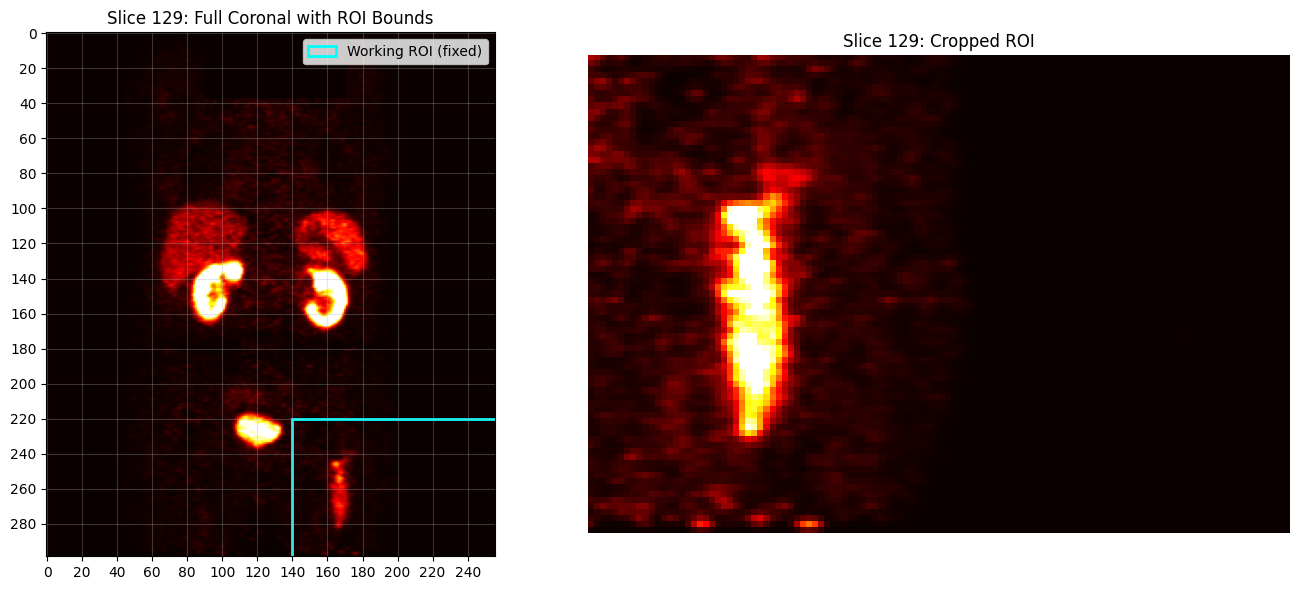

In [70]:
# ==============================================================================
# 2B. MULTI-SLICE DATA PREPARATION
# ==============================================================================

# Extract and process all slices in the range  # Extrae y procesa todos los cortes dentro del rango definido.
multi_slice_data = {}  # Crea un diccionario vacío para almacenar los datos procesados de cada corte.

for slice_idx in SLICE_RANGE:  # Recorre cada índice de corte definido en SLICE_RANGE.
    coronal_raw = spect_array[:, slice_idx, :]  # Extrae el corte coronal original desde el arreglo SPECT usando el índice actual.
    coronal_vis = np.fliplr(np.rot90(coronal_raw, 2))  # Rota el corte 180 grados y luego lo invierte horizontalmente para ajustarlo a la visualización.
    
    # Apply the SAME ROI cropping to all slices  # Aplica el mismo recorte de la ROI a todos los cortes.
    roi_img = coronal_vis[ROI_CROP[0]:, ROI_CROP[1]:]  # Recorta la imagen coronal usando las coordenadas iniciales definidas en ROI_CROP.
    
    multi_slice_data[slice_idx] = {  # Guarda la información del corte actual dentro del diccionario usando slice_idx como clave.
        'slice_index': slice_idx,  # Guarda el índice del corte actual.
        'coronal_raw': coronal_raw,  # Guarda el corte coronal original sin transformar.
        'coronal_vis': coronal_vis,  # Guarda el corte coronal transformado para visualización.
        'roi_img': roi_img  # Guarda la imagen recortada correspondiente a la región de interés.
    }  # Cierra el diccionario de datos asociado al corte actual.

print(f"✓ Multi-slice data prepared")  # Imprime un mensaje indicando que los datos de múltiples cortes fueron preparados correctamente.
print(f"  - Slices processed: {len(SLICE_RANGE)}")  # Imprime la cantidad total de cortes procesados.
print(f"  - Slice range: {START_SLICE}-{END_SLICE}")  # Imprime el rango de cortes procesados, desde START_SLICE hasta END_SLICE.
print(f"  - ROI shape (fixed for all): {list(multi_slice_data[START_SLICE]['roi_img'].shape)}")  # Imprime la forma de la ROI recortada, que se mantiene fija para todos los cortes.

# Visualize first slice as example  # Selecciona el primer corte como ejemplo para visualizar o inspeccionar sus datos.
example_slice = START_SLICE  # Define como ejemplo el primer corte del rango.
example_data = multi_slice_data[example_slice]  # Obtiene del diccionario los datos correspondientes al corte de ejemplo.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full coronal image
axes[0].imshow(
    example_data['coronal_vis'],
    cmap="hot",
    vmin=0,
    vmax=np.percentile(example_data['coronal_vis'], 99)
)

axes[0].set_xticks(np.arange(0, example_data['coronal_vis'].shape[1], 20))
axes[0].set_yticks(np.arange(0, example_data['coronal_vis'].shape[0], 20))
axes[0].grid(True, alpha=0.3)

roi_rect = patches.Rectangle(
    (ROI_CROP[1], ROI_CROP[0]),
    example_data['coronal_vis'].shape[1] - ROI_CROP[1],
    example_data['coronal_vis'].shape[0] - ROI_CROP[0],
    linewidth=2,
    edgecolor="cyan",
    facecolor="none",
    label="Working ROI (fixed)"
)
axes[0].add_patch(roi_rect)
axes[0].set_title(f"Slice {example_slice}: Full Coronal with ROI Bounds")
axes[0].legend()

# Cropped ROI
axes[1].imshow(
    example_data['roi_img'],
    cmap="hot",
    vmin=0,
    vmax=np.percentile(example_data['roi_img'], 99)
)
axes[1].set_title(f"Slice {example_slice}: Cropped ROI")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Stage 2: Initial Lesion Mask (ROI0)

✓ Initial mask (ROI0) created
  - Threshold: 65% of max = 15539.98
  - Mask size: 14 voxels


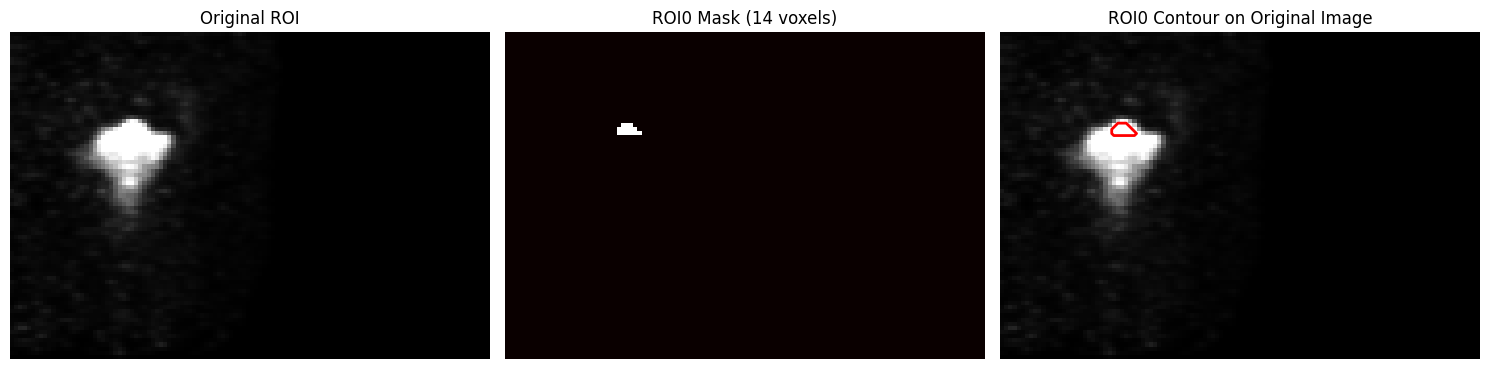

In [71]:
# Create initial lesion mask (ROI0)
threshold = THRESHOLD_PERCENTILE * roi_img.max()
mask0 = roi_img > threshold

print(f"✓ Initial mask (ROI0) created")
print(f"  - Threshold: {THRESHOLD_PERCENTILE * 100:.0f}% of max = {threshold:.2f}")
print(f"  - Mask size: {mask0.sum()} voxels")

# Visualize initial mask
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0].set_title("Original ROI")
axes[0].axis('off')

axes[1].imshow(mask0, cmap="hot")
axes[1].set_title(f"ROI0 Mask ({mask0.sum()} voxels)")
axes[1].axis('off')

axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='r', linewidths=2)
axes[2].set_title("ROI0 Contour on Original Image")
axes[2].axis('off')

plt.tight_layout()
plt.show()

Creating initial masks for 12 slices...

Slice 129: Threshold= 8825.69 | ROI0 size=   31 voxels
Slice 130: Threshold=14274.30 | ROI0 size=   13 voxels
Slice 131: Threshold=16990.83 | ROI0 size=   11 voxels
Slice 132: Threshold=16256.51 | ROI0 size=   36 voxels
Slice 133: Threshold=14686.42 | ROI0 size=   78 voxels
Slice 134: Threshold=18954.26 | ROI0 size=   27 voxels
Slice 135: Threshold=19763.07 | ROI0 size=   13 voxels
Slice 136: Threshold=16519.39 | ROI0 size=   25 voxels
Slice 137: Threshold=12639.98 | ROI0 size=   76 voxels
Slice 138: Threshold=15038.85 | ROI0 size=   18 voxels
Slice 139: Threshold=16051.40 | ROI0 size=   14 voxels
Slice 140: Threshold=15539.98 | ROI0 size=   14 voxels

✓ Initial masks created for all slices


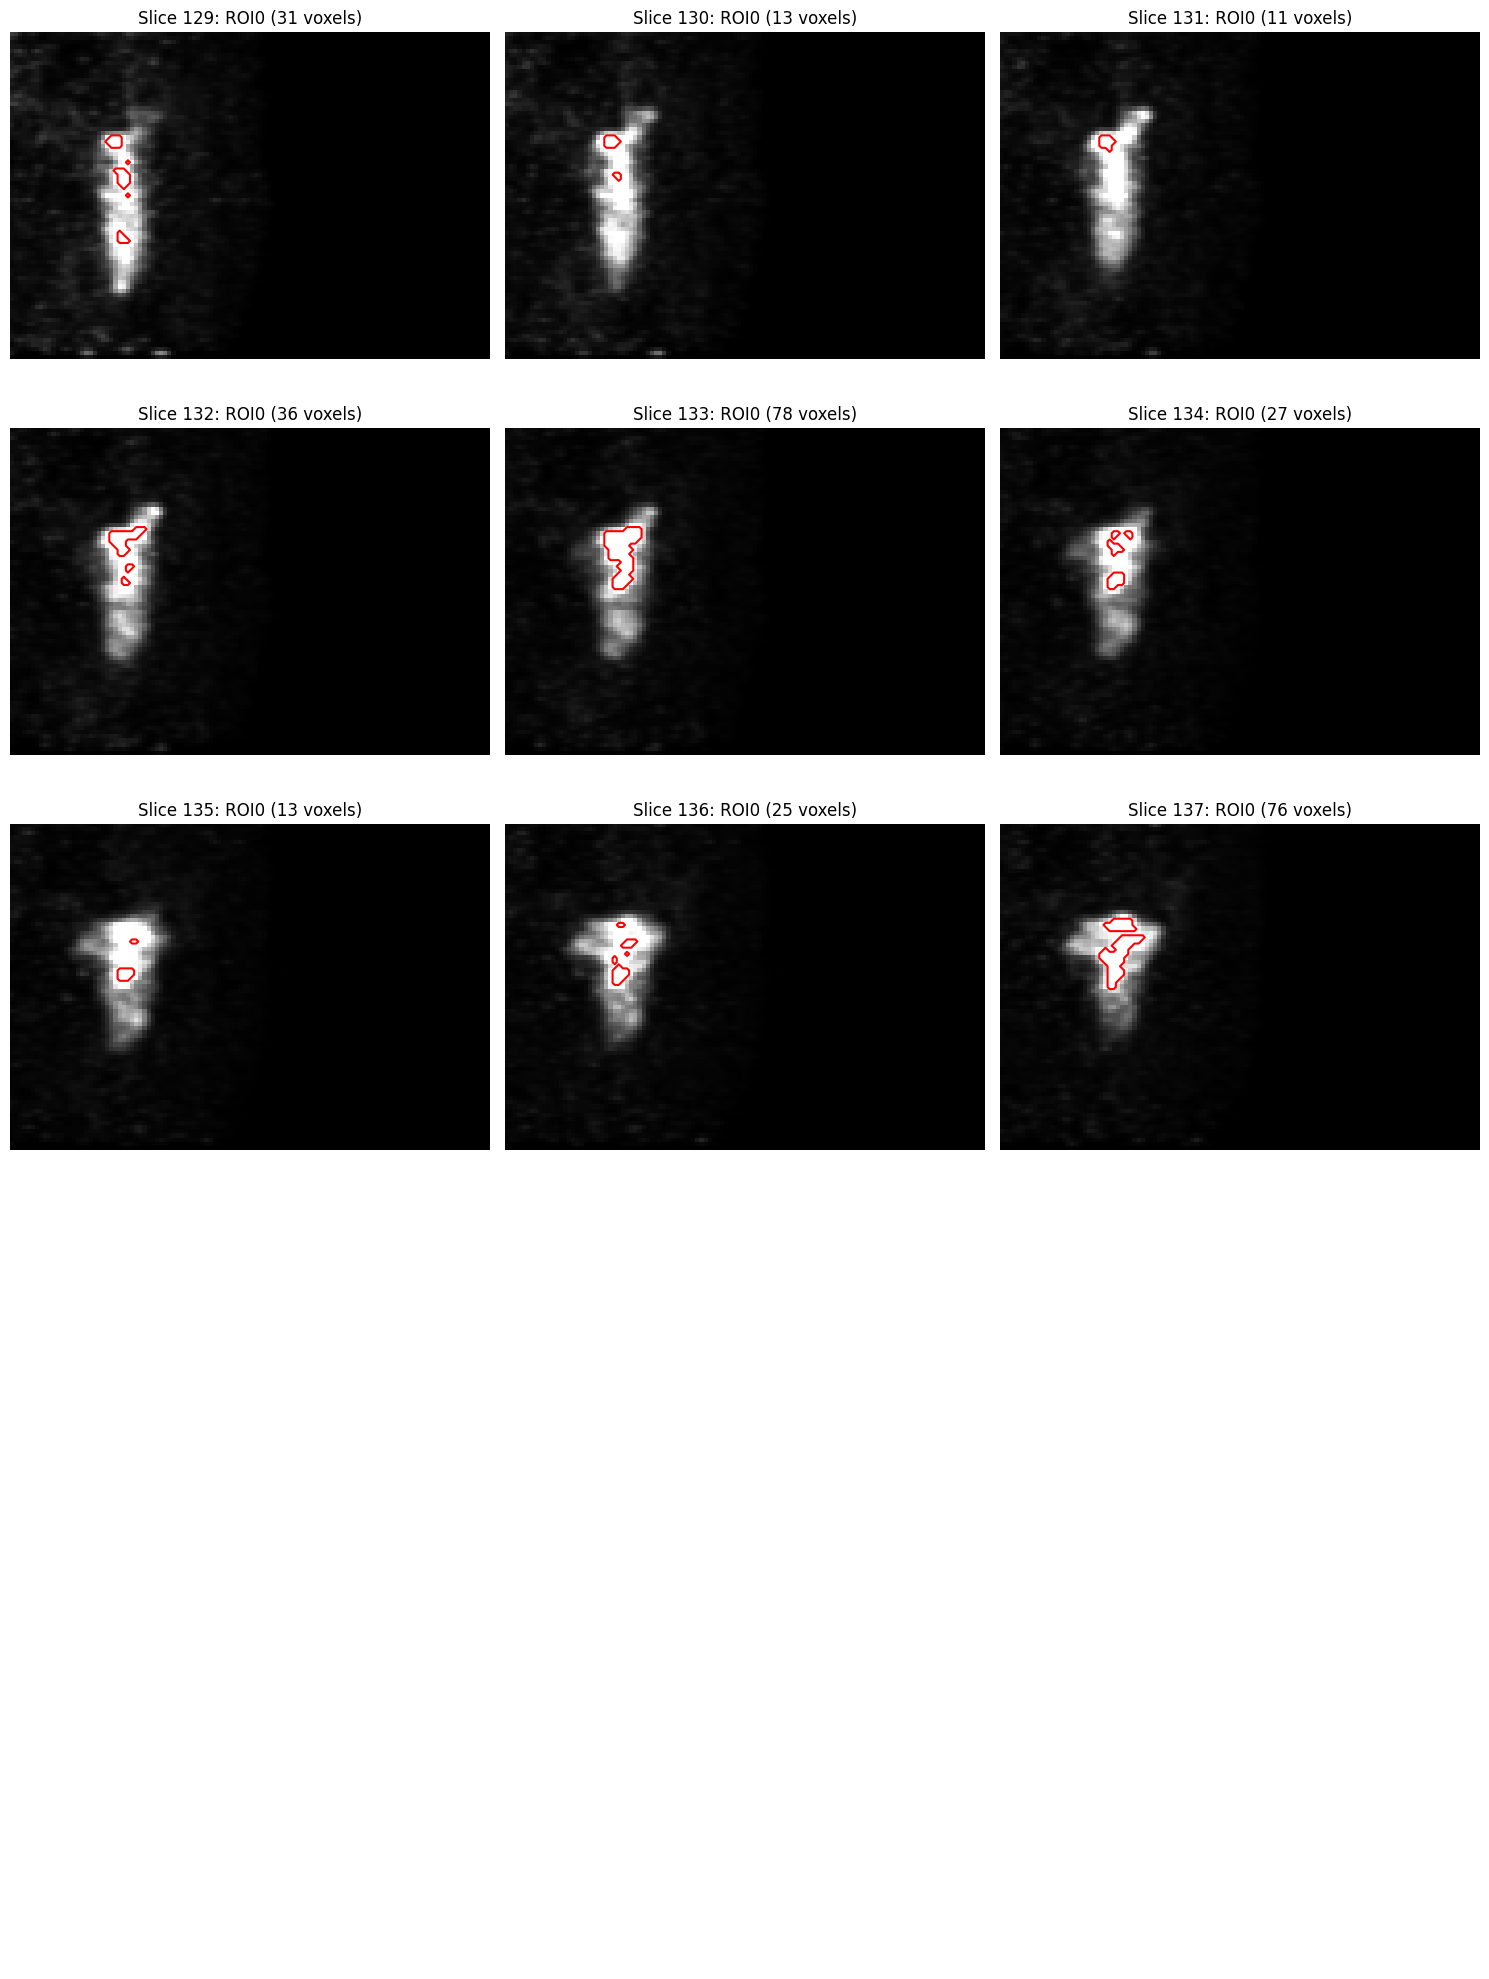

In [72]:
# ==============================================================================
# 3. INITIAL LESION MASKS (ROI0) FOR ALL SLICES
# ==============================================================================

print(f"Creating initial masks for {len(SLICE_RANGE)} slices...\n")

for slice_idx in SLICE_RANGE:  # Recorre cada índice de corte definido en SLICE_RANGE.
    roi_img = multi_slice_data[slice_idx]['roi_img']  # Obtiene la imagen ROI recortada correspondiente al corte actual.
    
    # Create initial lesion mask  # Crea la máscara inicial de la lesión para el corte actual.
    threshold = THRESHOLD_PERCENTILE * roi_img.max()  # Calcula el umbral como una fracción del valor máximo de intensidad dentro de la ROI.
    mask0 = roi_img > threshold  # Crea una máscara booleana donde los voxeles con intensidad mayor al umbral se consideran parte de la ROI inicial.
    
    multi_slice_data[slice_idx]['mask0'] = mask0  # Guarda la máscara inicial dentro del diccionario del corte actual.
    multi_slice_data[slice_idx]['threshold'] = threshold  # Guarda el valor del umbral usado para generar la máscara inicial.
    
    print(f"Slice {slice_idx:3d}: Threshold={threshold:8.2f} | ROI0 size={mask0.sum():5d} voxels")  # Imprime el índice del corte, el umbral calculado y el tamaño de la máscara inicial en voxeles.

print(f"\n✓ Initial masks created for all slices")  # Imprime un mensaje indicando que las máscaras iniciales fueron creadas para todos los cortes.

# Visualize masks for first 3 slices  # Visualiza las máscaras iniciales para un conjunto de cortes.
fig, axes = plt.subplots(len(SLICE_RANGE)//3 + 1, 3, figsize=(15, 4 * (len(SLICE_RANGE)//3 + 1)))  # Crea una figura con subgráficas organizadas en 3 columnas para mostrar varias imágenes.
axes = axes.flatten()  # Convierte la matriz de ejes en una lista unidimensional para recorrerlos fácilmente.

for idx, slice_idx in enumerate(SLICE_RANGE[:9]):  # Recorre como máximo los primeros 9 cortes para visualizarlos.
    roi_img = multi_slice_data[slice_idx]['roi_img']  # Obtiene la imagen ROI recortada correspondiente al corte actual.
    mask0 = multi_slice_data[slice_idx]['mask0']  # Obtiene la máscara inicial asociada al corte actual.
    
    
    axes[idx].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
    axes[idx].contour(mask0, colors='r', linewidths=1.5)
    axes[idx].set_title(f"Slice {slice_idx}: ROI0 ({mask0.sum()} voxels)")
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(len(SLICE_RANGE[:9]), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [73]:
# Initialize PyRadiomics feature extractor
extractor = featureextractor.RadiomicsFeatureExtractor()
extractor.disableAllFeatures()
extractor.enableFeaturesByName(**{FEATURE_CLASS: [FEATURE_NAME]})

print(f"✓ PyRadiomics extractor initialized")
print(f"  - Feature: {FEATURE_CLASS}.{FEATURE_NAME}")
print(f"  - Voxel-based extraction enabled")

✓ PyRadiomics extractor initialized
  - Feature: firstorder.Median
  - Voxel-based extraction enabled


In [74]:
def reconstruct_voxel_map(result_dict, reference_shape, feature_key):
    """
    Reconstruct full-size voxel-based radiomic map from PyRadiomics bounding box coordinates.
    
    PyRadiomics returns voxel-based maps in bounding-box coordinates (smaller array).
    This function reconstructs the map into full-image coordinates.
    
    Parameters
    ----------
    result_dict : dict
        PyRadiomics extraction result dict
    reference_shape : tuple
        Shape of the full image (height, width)
    feature_key : str
        Feature key to extract from the PyRadiomics result dict
    
    Returns
    -------
    np.ndarray
        Full-size radiomic map with same shape as reference_shape
    """
    # Extract bounding box from PyRadiomics result
    # BoundingBox format: (x, y, z, size_x, size_y, size_z)
    bbox_key = "diagnostics_Mask-original_BoundingBox"
    if bbox_key not in result_dict:
        raise ValueError(f"Bounding box not found in result. Available keys: {result_dict.keys()}")
    
    bbox = result_dict[bbox_key]
    x, y, z, sx, sy, sz = bbox
    
    # Extract the 2D voxel-based map (z=0 for 2D analysis)
    if feature_key not in result_dict:
        raise ValueError(
            f"Feature key '{feature_key}' not found in result. Available keys: {list(result_dict.keys())}"
        )
    feature_img = result_dict[feature_key]
    median_map = sitk.GetArrayFromImage(feature_img)[0]  # Extract first (only) z-slice
    
    # Reconstruct full map with bounding box positioning
    full_map = np.zeros(reference_shape, dtype=float)
    
    h, w = median_map.shape
    x0 = x - 1  # PyRadiomics uses 1-based indexing
    y0 = y - 1
    
    full_map[
        y0:y0 + h,
        x0:x0 + w
    ] = median_map
    
    return full_map, (x0, y0, h, w)

print("✓ Utility function 'reconstruct_voxel_map' defined")

✓ Utility function 'reconstruct_voxel_map' defined


## Stage 4: Reference Distribution (ROI0 Voxel-Based Statistics)

In [75]:

print(f"Computing reference distributions for {len(SLICE_RANGE)} slices...\n")  

for slice_idx in SLICE_RANGE:  # Recorre cada índice de corte definido en SLICE_RANGE.
    roi_img = multi_slice_data[slice_idx]['roi_img']  # Obtiene la imagen ROI recortada correspondiente al corte actual.
    mask0 = multi_slice_data[slice_idx]['mask0']  # Obtiene la máscara inicial ROI0 correspondiente al corte actual.
    
    # Convert to 3D format required by PyRadiomics  # Convierte los datos al formato 3D requerido por PyRadiomics.
    img_3d = roi_img[np.newaxis, :, :].astype(np.float32)  # Agrega una dimensión extra a la imagen ROI y la convierte a tipo float32.
    mask0_3d = mask0[np.newaxis, :, :].astype(np.uint8)  # Agrega una dimensión extra a la máscara ROI0 y la convierte a tipo entero uint8.
    
    sitk_img = sitk.GetImageFromArray(img_3d)  # Convierte el arreglo NumPy de la imagen 3D en una imagen SimpleITK.
    sitk_mask0 = sitk.GetImageFromArray(mask0_3d)  # Convierte el arreglo NumPy de la máscara 3D en una máscara SimpleITK.
    
    # Extract voxel-based radiomic map  
    result_roi0 = extractor.execute(sitk_img, sitk_mask0, voxelBased=True)  # Ejecuta PyRadiomics sobre la imagen y la máscara ROI0 para obtener características radiómicas voxel a voxel.
    
    # Reconstruct full map and extract ROI0 voxel values  # Reconstruye el mapa completo y extrae los valores de los voxeles dentro de ROI0.
    voxel_map_roi0, bbox_info = reconstruct_voxel_map(result_roi0, roi_img.shape, FEATURE_KEY)  # Reconstruye el mapa radiómico completo usando la característica definida en FEATURE_KEY.
    vals_roi0 = voxel_map_roi0[mask0]  # Extrae del mapa radiómico solo los valores correspondientes a los voxeles incluidos en la máscara ROI0.
    
    # Compute statistics  # Calcula las estadísticas de referencia.
    mean_ref = vals_roi0.mean()  # Calcula el promedio de los valores radiómicos dentro de ROI0.
    std_ref = vals_roi0.std()  # Calcula la desviación estándar de los valores radiómicos dentro de ROI0.
    
    # Define acceptance limits (fixed for this slice throughout all iterations)  # Define los límites de aceptación fijos para este corte durante todas las iteraciones.
    lower_limit = mean_ref - K_VALUE * std_ref  # Calcula el límite inferior de aceptación como media menos K_VALUE veces la desviación estándar.
    upper_limit = mean_ref + K_VALUE * std_ref  # Calcula el límite superior de aceptación como media más K_VALUE veces la desviación estándar.
    
    # Store in multi-slice data structure  # Guarda los resultados en la estructura de datos de múltiples cortes.
    multi_slice_data[slice_idx]['voxel_map_roi0'] = voxel_map_roi0  # Guarda el mapa radiómico reconstruido de ROI0 para el corte actual.
    multi_slice_data[slice_idx]['vals_roi0'] = vals_roi0  # Guarda los valores radiómicos extraídos dentro de la máscara ROI0.
    multi_slice_data[slice_idx]['mean_ref'] = mean_ref  # Guarda la media de referencia calculada para el corte actual.
    multi_slice_data[slice_idx]['std_ref'] = std_ref  # Guarda la desviación estándar de referencia calculada para el corte actual.
    multi_slice_data[slice_idx]['lower_limit'] = lower_limit  # Guarda el límite inferior de aceptación para el corte actual.
    multi_slice_data[slice_idx]['upper_limit'] = upper_limit  # Guarda el límite superior de aceptación para el corte actual.
    
    print(f"Slice {slice_idx:3d}: Mean={mean_ref:8.4f} | Std={std_ref:8.4f} | "  # Imprime el índice del corte, la media y la desviación estándar de referencia.
          f"Bounds=[{lower_limit:8.4f}, {upper_limit:8.4f}] | N={len(vals_roi0):5d}")  # Continúa el mensaje imprimiendo los límites de aceptación y el número de voxeles analizados.

print(f"\n✓ Reference distributions computed for all slices")  # Imprime un mensaje indicando que las distribuciones de referencia fueron calculadas para todos los cortes.

Computing reference distributions for 12 slices...

Slice 129: Mean=10662.8415 | Std=969.7464 | Bounds=[965.3771, 20360.3058] | N=   31
Slice 130: Mean=17558.1964 | Std=1538.6768 | Bounds=[2171.4281, 32944.9648] | N=   13
Slice 131: Mean=21915.3511 | Std=937.3280 | Bounds=[12542.0716, 31288.6306] | N=   11
Slice 132: Mean=19190.6471 | Std=1795.3522 | Bounds=[1237.1250, 37144.1692] | N=   36
Slice 133: Mean=18480.6978 | Std=1488.9698 | Bounds=[3590.9997, 33370.3960] | N=   78
Slice 134: Mean=21569.5425 | Std=1942.7262 | Bounds=[2142.2807, 40996.8044] | N=   27
Slice 135: Mean=24224.1795 | Std=1742.4623 | Bounds=[6799.5569, 41648.8021] | N=   13
Slice 136: Mean=18762.5357 | Std=1634.0400 | Bounds=[2422.1358, 35102.9357] | N=   25
Slice 137: Mean=14804.6601 | Std=1085.4980 | Bounds=[3949.6799, 25659.6404] | N=   76
Slice 138: Mean=17688.0712 | Std=1132.2443 | Bounds=[6365.6283, 29010.5141] | N=   18
Slice 139: Mean=19634.0956 | Std=1314.4901 | Bounds=[6489.1948, 32778.9963] | N=   14
Slic

## Stage 5: Iterative Region Growing

In [76]:

print(f"Starting iterative region growing for {len(SLICE_RANGE)} slices ({NUM_ITERATIONS} iterations each)...\n")  

for slice_idx in SLICE_RANGE:  # Recorre cada índice de corte definido en SLICE_RANGE.
    print(f"\n{'='*80}")  # Imprime una línea separadora de 80 signos igual antes de procesar el corte.
    print(f"Processing Slice {slice_idx}")  # Imprime el índice del corte que se está procesando.
    print(f"{'='*80}")  # Imprime otra línea separadora de 80 signos igual.
    
    roi_img = multi_slice_data[slice_idx]['roi_img']  # Obtiene la imagen ROI recortada correspondiente al corte actual.
    mask0 = multi_slice_data[slice_idx]['mask0']  # Obtiene la máscara inicial ROI0 correspondiente al corte actual.
    mean_ref = multi_slice_data[slice_idx]['mean_ref']  # Obtiene la media de referencia calculada para el corte actual.
    std_ref = multi_slice_data[slice_idx]['std_ref']  # Obtiene la desviación estándar de referencia calculada para el corte actual.
    lower_limit = multi_slice_data[slice_idx]['lower_limit']  # Obtiene el límite inferior de aceptación para el corte actual.
    upper_limit = multi_slice_data[slice_idx]['upper_limit']  # Obtiene el límite superior de aceptación para el corte actual.
    
    # Convert to 3D format for PyRadiomics  # Convierte la imagen ROI al formato 3D requerido por PyRadiomics.
    img_3d = roi_img[np.newaxis, :, :].astype(np.float32)  # Agrega una dimensión extra a la imagen ROI y la convierte a tipo float32.
    sitk_img = sitk.GetImageFromArray(img_3d)  # Convierte el arreglo NumPy 3D de la imagen en una imagen SimpleITK.
    
    # Initialize iterative region growing  # Inicializa las variables necesarias para el crecimiento regional iterativo.
    roi_current = mask0.copy()  # Crea una copia de la máscara inicial ROI0 para usarla como ROI actual.
    results = []  # Inicializa una lista vacía donde se guardarán los resultados numéricos de cada iteración.
    history = []  # Inicializa una lista vacía donde se guardará información detallada de cada iteración.
    
    for iteration in range(1, NUM_ITERATIONS + 1):  # Inicia el ciclo iterativo desde 1 hasta NUM_ITERATIONS.
        # Step 1: Generate candidate voxels via dilation  # Paso 1: genera voxeles candidatos mediante dilatación de la ROI actual.
        roi_dilated = binary_dilation(roi_current)  # Dilata la ROI actual para expandirla un voxel alrededor de sus bordes.
        corona = roi_dilated & (~roi_current)  # Obtiene solo los nuevos voxeles agregados por la dilatación, excluyendo la ROI actual.
        
        # Step 2: Compute voxel-based feature map on dilated ROI  # Paso 2: calcula el mapa de características voxel a voxel sobre la ROI dilatada.
        mask_3d = roi_dilated.astype(np.uint8)[np.newaxis, :, :]  # Convierte la ROI dilatada a uint8 y agrega una dimensión extra para formar una máscara 3D.
        sitk_mask = sitk.GetImageFromArray(mask_3d)  # Convierte la máscara 3D en una imagen SimpleITK para usarla en PyRadiomics.
        
        result = extractor.execute(sitk_img, sitk_mask, voxelBased=True)  # Ejecuta PyRadiomics para extraer características radiómicas voxel a voxel dentro de la ROI dilatada.
        
        # Step 3: Reconstruct full-size map from PyRadiomics bounding box  # Paso 3: reconstruye el mapa completo a partir de la caja delimitadora generada por PyRadiomics.
        full_map, _ = reconstruct_voxel_map(result, roi_img.shape, FEATURE_KEY)  # Reconstruye el mapa radiómico completo con la forma original de la ROI.
        
        # Step 4: Extract radiomic values for corona voxels  # Paso 4: extrae los valores radiómicos de los voxeles candidatos de la corona.
        corona_values = full_map[corona]  # Obtiene del mapa completo solo los valores correspondientes a los voxeles de la corona.
        
        # Step 5: Classify voxels (accept if within statistical bounds)  # Paso 5: clasifica los voxeles aceptándolos si están dentro de los límites estadísticos.
        accepted = (  # Crea una máscara booleana indicando qué voxeles candidatos cumplen los criterios de aceptación.
            (corona_values >= lower_limit) &  # Evalúa si cada valor de la corona es mayor o igual al límite inferior.
            (corona_values <= upper_limit)  # Evalúa si cada valor de la corona es menor o igual al límite superior.
        )  
        
        # Step 6: Create mask of accepted voxels  # Paso 6: crea una máscara con los voxeles aceptados.
        mask_accepted = np.zeros_like(roi_current, dtype=bool)  # Crea una máscara booleana vacía con la misma forma que la ROI actual.
        mask_accepted[corona] = accepted  # Marca como verdaderos los voxeles de la corona que fueron aceptados.
        
        # Step 7: Update ROI with accepted voxels  # Paso 7: actualiza la ROI agregando los voxeles aceptados.
        roi_new = roi_current | mask_accepted  # Combina la ROI actual con los voxeles aceptados para formar la nueva ROI.
        
        # Step 8: Store results  # Paso 8: guarda los resultados de la iteración actual.
        n_accepted = accepted.sum()  # Cuenta cuántos voxeles candidatos fueron aceptados.
        n_rejected = (~accepted).sum()  # Cuenta cuántos voxeles candidatos fueron rechazados.
        
        results.append({  # Agrega al listado de resultados un diccionario con el resumen numérico de la iteración.
            "Iteration": iteration,  # Guarda el número de la iteración actual.
            "Current ROI Size": roi_current.sum(),  # Guarda el tamaño de la ROI antes de agregar los nuevos voxeles.
            "Corona Size": corona.sum(),  # Guarda el número de voxeles candidatos en la corona.
            "Accepted": n_accepted,  # Guarda el número de voxeles aceptados.
            "Rejected": n_rejected,  # Guarda el número de voxeles rechazados.
            "New ROI Size": roi_new.sum()  # Guarda el tamaño de la ROI después de agregar los voxeles aceptados.
        })  # Cierra el diccionario agregado a la lista de resultados.
        
        history.append({  # Agrega al historial un diccionario con copias detalladas de los datos de la iteración.
            "iteration": iteration,  # Guarda el número de la iteración actual.
            "roi_current": roi_current.copy(),  # Guarda una copia de la ROI actual antes de actualizarla.
            "roi_dilated": roi_dilated.copy(),  # Guarda una copia de la ROI dilatada.
            "corona": corona.copy(),  # Guarda una copia de la máscara de voxeles candidatos.
            "mask_accepted": mask_accepted.copy(),  # Guarda una copia de la máscara de voxeles aceptados.
            "corona_values": corona_values.copy(),  # Guarda una copia de los valores radiómicos de la corona.
            "voxel_map": full_map.copy()  # Guarda una copia del mapa radiómico completo de la iteración.
        })  # Cierra el diccionario agregado al historial.
        
        # Print progress  
        size_increase = roi_new.sum() - roi_current.sum()  # Calcula cuántos voxeles aumentó la ROI en esta iteración.
        print(f"Iter {iteration:2d}: ROI {roi_current.sum():4d} → {roi_new.sum():4d} "  # Imprime la iteración y el cambio de tamaño de la ROI.
              f"| Corona: {corona.sum():4d} | Acc: {n_accepted:4d} | Rej: {n_rejected:4d} | "  # Continúa imprimiendo el tamaño de la corona y los voxeles aceptados/rechazados.
              f"Growth: {size_increase:+4d}")  # Termina imprimiendo el crecimiento neto de la ROI en esta iteración.
        
        # Update for next iteration  # Actualiza la ROI para la siguiente iteración.
        roi_current = roi_new  # Reemplaza la ROI actual por la nueva ROI expandida.
    
    # Store results and history for this slice  # Guarda los resultados y el historial correspondientes al corte actual.
    multi_slice_data[slice_idx]['results'] = pd.DataFrame(results)  # Convierte la lista de resultados en un DataFrame y lo guarda para el corte actual.
    multi_slice_data[slice_idx]['history'] = history  # Guarda el historial detallado de iteraciones para el corte actual.
    multi_slice_data[slice_idx]['roi_final'] = roi_current  # Guarda la ROI final obtenida después de todas las iteraciones.
    
    print(f"✓ Slice {slice_idx} completed")  # Imprime un mensaje indicando que el procesamiento del corte actual terminó correctamente.

print(f"\n{'='*80}")  # Imprime una línea separadora final de 80 signos igual.
print(f"✓ Iterative region growing completed for all {len(SLICE_RANGE)} slices!")  # Imprime un mensaje indicando que el crecimiento regional terminó para todos los cortes.
print(f"{'='*80}")  # Imprime una última línea separadora de 80 signos igual.

Starting iterative region growing for 12 slices (15 iterations each)...


Processing Slice 129
Iter  1: ROI   31 →   75 | Corona:   44 | Acc:   44 | Rej:    0 | Growth:  +44
Iter  2: ROI   75 →  130 | Corona:   55 | Acc:   55 | Rej:    0 | Growth:  +55
Iter  3: ROI  130 →  192 | Corona:   63 | Acc:   62 | Rej:    1 | Growth:  +62
Iter  4: ROI  192 →  255 | Corona:   68 | Acc:   63 | Rej:    5 | Growth:  +63
Iter  5: ROI  255 →  322 | Corona:   76 | Acc:   67 | Rej:    9 | Growth:  +67
Iter  6: ROI  322 →  386 | Corona:   77 | Acc:   64 | Rej:   13 | Growth:  +64
Iter  7: ROI  386 →  444 | Corona:   80 | Acc:   58 | Rej:   22 | Growth:  +58
Iter  8: ROI  444 →  493 | Corona:   85 | Acc:   49 | Rej:   36 | Growth:  +49
Iter  9: ROI  493 →  535 | Corona:   89 | Acc:   42 | Rej:   47 | Growth:  +42
Iter 10: ROI  535 →  570 | Corona:   96 | Acc:   35 | Rej:   61 | Growth:  +35
Iter 11: ROI  570 →  594 | Corona:  101 | Acc:   24 | Rej:   77 | Growth:  +24
Iter 12: ROI  594 →  617 | Corona:  

## Stage 6: Results & Visualizations

In [77]:

print("\n" + "="*100)  
print("MULTI-SLICE RADIOMICS-GUIDED REGION GROWING - SUMMARY")  
print("="*100 + "\n")  

summary_list = []  # Inicializa una lista vacía donde se guardará el resumen de resultados de cada corte.

for slice_idx in SLICE_RANGE:  # Recorre cada índice de corte definido en SLICE_RANGE.
    mask0 = multi_slice_data[slice_idx]['mask0']  # Obtiene la máscara inicial ROI0 correspondiente al corte actual.
    roi_final = multi_slice_data[slice_idx]['roi_final']  # Obtiene la ROI final obtenida después del crecimiento regional iterativo.
    mean_ref = multi_slice_data[slice_idx]['mean_ref']  # Obtiene la media de referencia calculada para el corte actual.
    std_ref = multi_slice_data[slice_idx]['std_ref']  # Obtiene la desviación estándar de referencia calculada para el corte actual.
    
    total_growth = roi_final.sum() - mask0.sum()  # Calcula cuántos voxeles se agregaron a la ROI final respecto a la ROI inicial.
    percent_growth = (total_growth / mask0.sum()) * 100  # Calcula el porcentaje de crecimiento de la ROI respecto a su tamaño inicial.
    
    summary_list.append({  # Agrega a la lista un diccionario con el resumen del corte actual.
        "Slice": slice_idx,  # Guarda el índice del corte.
        "Initial ROI0": mask0.sum(),  # Guarda el número de voxeles de la máscara inicial ROI0.
        "Final ROI": roi_final.sum(),  # Guarda el número de voxeles de la ROI final.
        "Voxels Added": total_growth,  # Guarda el número total de voxeles agregados durante el crecimiento regional.
        "Growth %": f"{percent_growth:.1f}%",  # Guarda el porcentaje de crecimiento formateado con una cifra decimal.
        "Mean (Ref)": f"{mean_ref:.4f}",  # Guarda la media de referencia formateada con cuatro decimales.
        "Std (Ref)": f"{std_ref:.4f}"  # Guarda la desviación estándar de referencia formateada con cuatro decimales.
    })  # Cierra el diccionario agregado al resumen.

df_summary = pd.DataFrame(summary_list)  # Convierte la lista de resúmenes en un DataFrame de pandas.
print(df_summary.to_string(index=False))  # Imprime el DataFrame como texto sin mostrar el índice de las filas.
print("\n" + "="*100)  

# Overall statistics  # Calcula estadísticas globales considerando todos los cortes.
total_initial = sum(multi_slice_data[s]['mask0'].sum() for s in SLICE_RANGE)  # Suma el número de voxeles iniciales ROI0 en todos los cortes.
total_final = sum(multi_slice_data[s]['roi_final'].sum() for s in SLICE_RANGE)  # Suma el número de voxeles finales en todos los cortes.
total_added = total_final - total_initial  # Calcula el número total de voxeles agregados en todos los cortes.

print(f"\nOVERALL STATISTICS (All {len(SLICE_RANGE)} slices):")  # Imprime el encabezado de las estadísticas globales indicando el número de cortes.
print(f"  - Total initial voxels (all ROI0s): {total_initial}")  # Imprime el total de voxeles iniciales sumados entre todas las ROI0.
print(f"  - Total final voxels (all final ROIs): {total_final}")  # Imprime el total de voxeles finales sumados entre todas las ROIs finales.
print(f"  - Total voxels added: {total_added}")  # Imprime el número total de voxeles agregados durante el proceso completo.
print(f"  - Mean growth per slice: {total_added / len(SLICE_RANGE):.0f} voxels")  # Imprime el crecimiento promedio por corte en voxeles.


MULTI-SLICE RADIOMICS-GUIDED REGION GROWING - SUMMARY

 Slice  Initial ROI0  Final ROI  Voxels Added Growth % Mean (Ref) Std (Ref)
   129            31        664           633  2041.9% 10662.8415  969.7464
   130            13        367           354  2723.1% 17558.1964 1538.6768
   131            11         43            32   290.9% 21915.3511  937.3280
   132            36        523           487  1352.8% 19190.6471 1795.3522
   133            78        410           332   425.6% 18480.6978 1488.9698
   134            27        508           481  1781.5% 21569.5425 1942.7262
   135            13        278           265  2038.5% 24224.1795 1742.4623
   136            25        480           455  1820.0% 18762.5357 1634.0400
   137            76        374           298   392.1% 14804.6601 1085.4980
   138            18        261           243  1350.0% 17688.0712 1132.2443
   139            14        230           216  1542.9% 19634.0956 1314.4901
   140            14        219 


Detailed Visualization: Slice 137, Iteration 5
Reference bounds: [3949.6799, 25659.6404]
(Mean=14804.6601, Std=1085.4980)


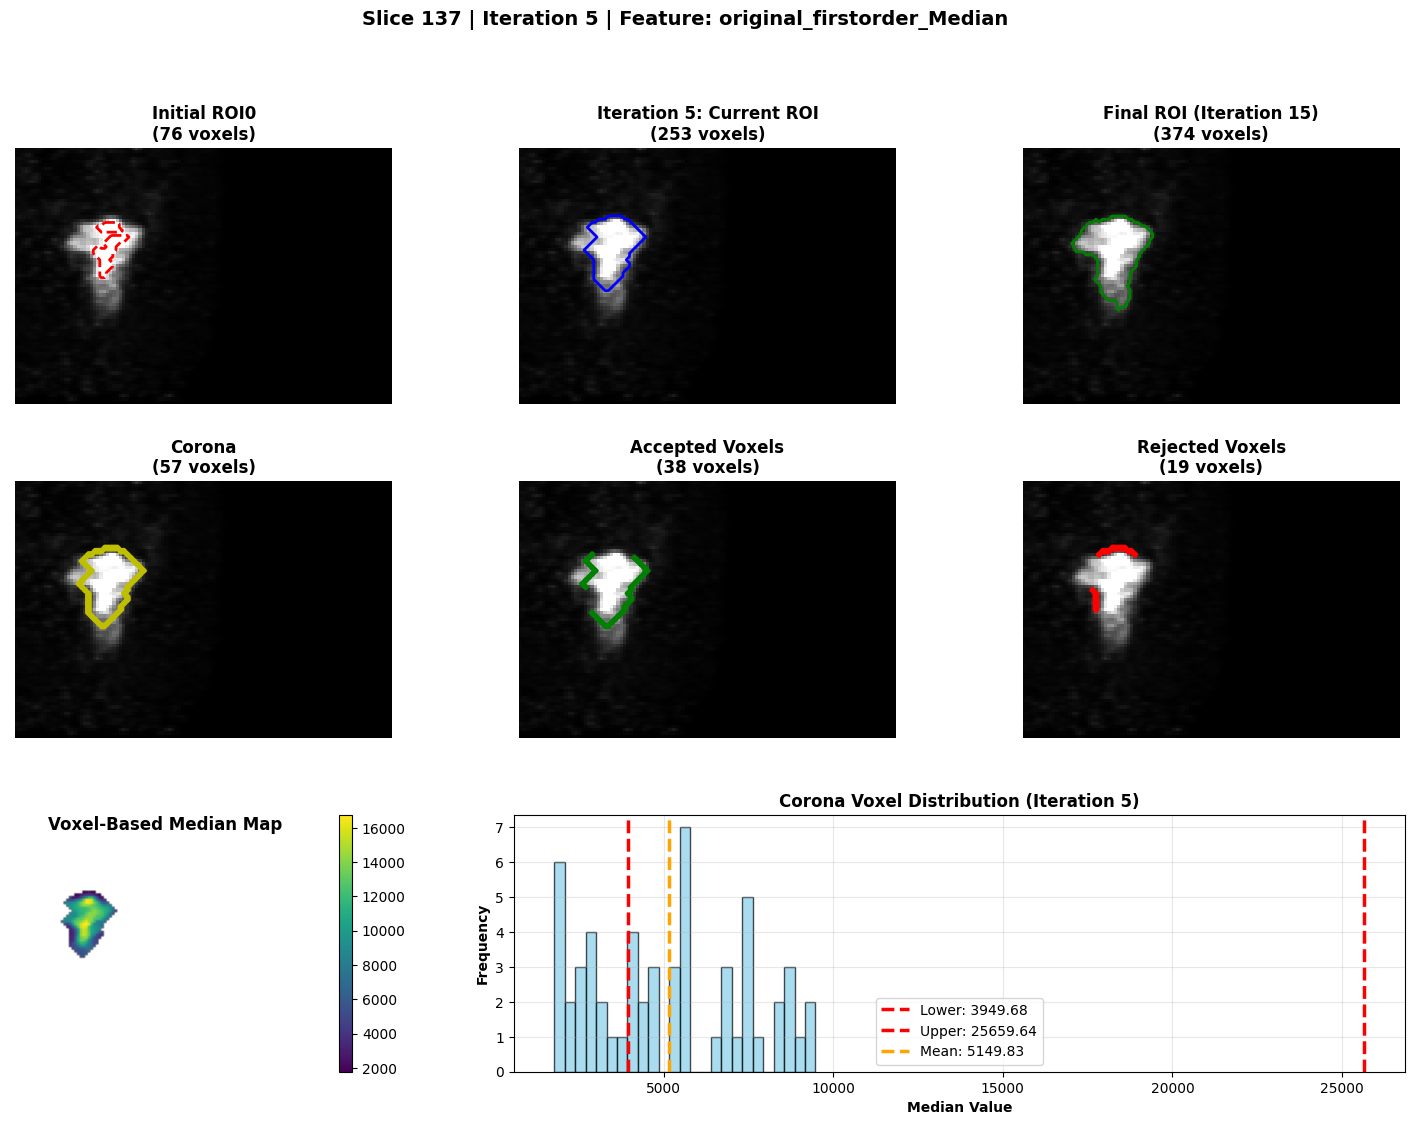


Iteration 5 Statistics (Slice 137):
  - Current ROI size: 253
  - Corona size: 57
  - Voxels accepted: 38
  - Voxels rejected: 19
  - New ROI size: 291


In [78]:
# ==============================================================================
# 6B. INTERACTIVE SLICE & ITERATION INSPECTION
# ==============================================================================

# SELECT SLICE AND ITERATION TO VISUALIZE
slice_to_show = 137        # Choose any slice in SLICE_RANGE
iteration_to_show = 5      # Choose iteration 1 to NUM_ITERATIONS

# Validate selection
if slice_to_show not in SLICE_RANGE:
    raise ValueError(f"slice_to_show={slice_to_show} not in SLICE_RANGE={list(SLICE_RANGE)}")
if iteration_to_show < 1 or iteration_to_show > NUM_ITERATIONS:
    raise ValueError(f"iteration_to_show={iteration_to_show} not in range 1-{NUM_ITERATIONS}")

# Extract data for selected slice and iteration
roi_img = multi_slice_data[slice_to_show]['roi_img']
mask0 = multi_slice_data[slice_to_show]['mask0']
mean_ref = multi_slice_data[slice_to_show]['mean_ref']
std_ref = multi_slice_data[slice_to_show]['std_ref']
lower_limit = multi_slice_data[slice_to_show]['lower_limit']
upper_limit = multi_slice_data[slice_to_show]['upper_limit']

data_iter = multi_slice_data[slice_to_show]['history'][iteration_to_show - 1]
results_df = multi_slice_data[slice_to_show]['results']

print(f"\nDetailed Visualization: Slice {slice_to_show}, Iteration {iteration_to_show}")
print(f"Reference bounds: [{lower_limit:.4f}, {upper_limit:.4f}]")
print(f"(Mean={mean_ref:.4f}, Std={std_ref:.4f})")

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Row 1: ROI Evolution
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
ax1.contour(mask0, colors='r', linewidths=2, linestyles='--')
ax1.set_title(f"Initial ROI0\n({mask0.sum()} voxels)", fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
ax2.contour(data_iter['roi_current'], colors='b', linewidths=2)
ax2.set_title(f"Iteration {iteration_to_show}: Current ROI\n({data_iter['roi_current'].sum()} voxels)", 
              fontweight='bold')
ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 2])
roi_final = multi_slice_data[slice_to_show]['roi_final']
ax3.imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
ax3.contour(roi_final, colors='g', linewidths=2)
ax3.set_title(f"Final ROI (Iteration {NUM_ITERATIONS})\n({roi_final.sum()} voxels)", fontweight='bold')
ax3.axis('off')

# Row 2: Corona Analysis
ax4 = fig.add_subplot(gs[1, 0])
ax4.imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
ax4.contour(data_iter['corona'], colors='y', linewidths=2.5)
ax4.set_title(f"Corona\n({data_iter['corona'].sum()} voxels)", fontweight='bold')
ax4.axis('off')

ax5 = fig.add_subplot(gs[1, 1])
ax5.imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
ax5.contour(data_iter['mask_accepted'], colors='g', linewidths=2.5)
ax5.set_title(f"Accepted Voxels\n({data_iter['mask_accepted'].sum()} voxels)", fontweight='bold')
ax5.axis('off')

ax6 = fig.add_subplot(gs[1, 2])
ax6.imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
rejected = data_iter['corona'] & (~data_iter['mask_accepted'])
ax6.contour(rejected, colors='r', linewidths=2.5)
ax6.set_title(f"Rejected Voxels\n({rejected.sum()} voxels)", fontweight='bold')
ax6.axis('off')

# Row 3: Voxel Map and Histogram
ax7 = fig.add_subplot(gs[2, 0])
voxel_map = data_iter['voxel_map']
voxel_map_masked = np.copy(voxel_map)
voxel_map_masked[voxel_map == 0] = np.nan
im = ax7.imshow(voxel_map_masked, cmap="viridis")
ax7.set_title(f"Voxel-Based {FEATURE_NAME} Map", fontweight='bold')
plt.colorbar(im, ax=ax7)
ax7.axis('off')

ax8 = fig.add_subplot(gs[2, 1:])
corona_vals = data_iter['corona_values']
valid_vals = corona_vals[corona_vals > 0]
ax8.hist(valid_vals, bins=25, edgecolor='k', alpha=0.7, color='skyblue')
ax8.axvline(lower_limit, color='r', linestyle='--', linewidth=2.5, label=f'Lower: {lower_limit:.2f}')
ax8.axvline(upper_limit, color='r', linestyle='--', linewidth=2.5, label=f'Upper: {upper_limit:.2f}')
ax8.axvline(valid_vals.mean(), color='orange', linestyle='--', linewidth=2.5, 
            label=f'Mean: {valid_vals.mean():.2f}')
ax8.set_xlabel(f"{FEATURE_NAME} Value", fontweight='bold')
ax8.set_ylabel("Frequency", fontweight='bold')
ax8.set_title(f"Corona Voxel Distribution (Iteration {iteration_to_show})", fontweight='bold')
ax8.legend(fontsize=10)
ax8.grid(alpha=0.3)

plt.suptitle(f"Slice {slice_to_show} | Iteration {iteration_to_show} | Feature: {FEATURE_KEY}", 
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

# Print iteration statistics
print(f"\nIteration {iteration_to_show} Statistics (Slice {slice_to_show}):")
iter_row = results_df[results_df['Iteration'] == iteration_to_show].iloc[0]
print(f"  - Current ROI size: {iter_row['Current ROI Size']}")
print(f"  - Corona size: {iter_row['Corona Size']}")
print(f"  - Voxels accepted: {iter_row['Accepted']}")
print(f"  - Voxels rejected: {iter_row['Rejected']}")
print(f"  - New ROI size: {iter_row['New ROI Size']}")

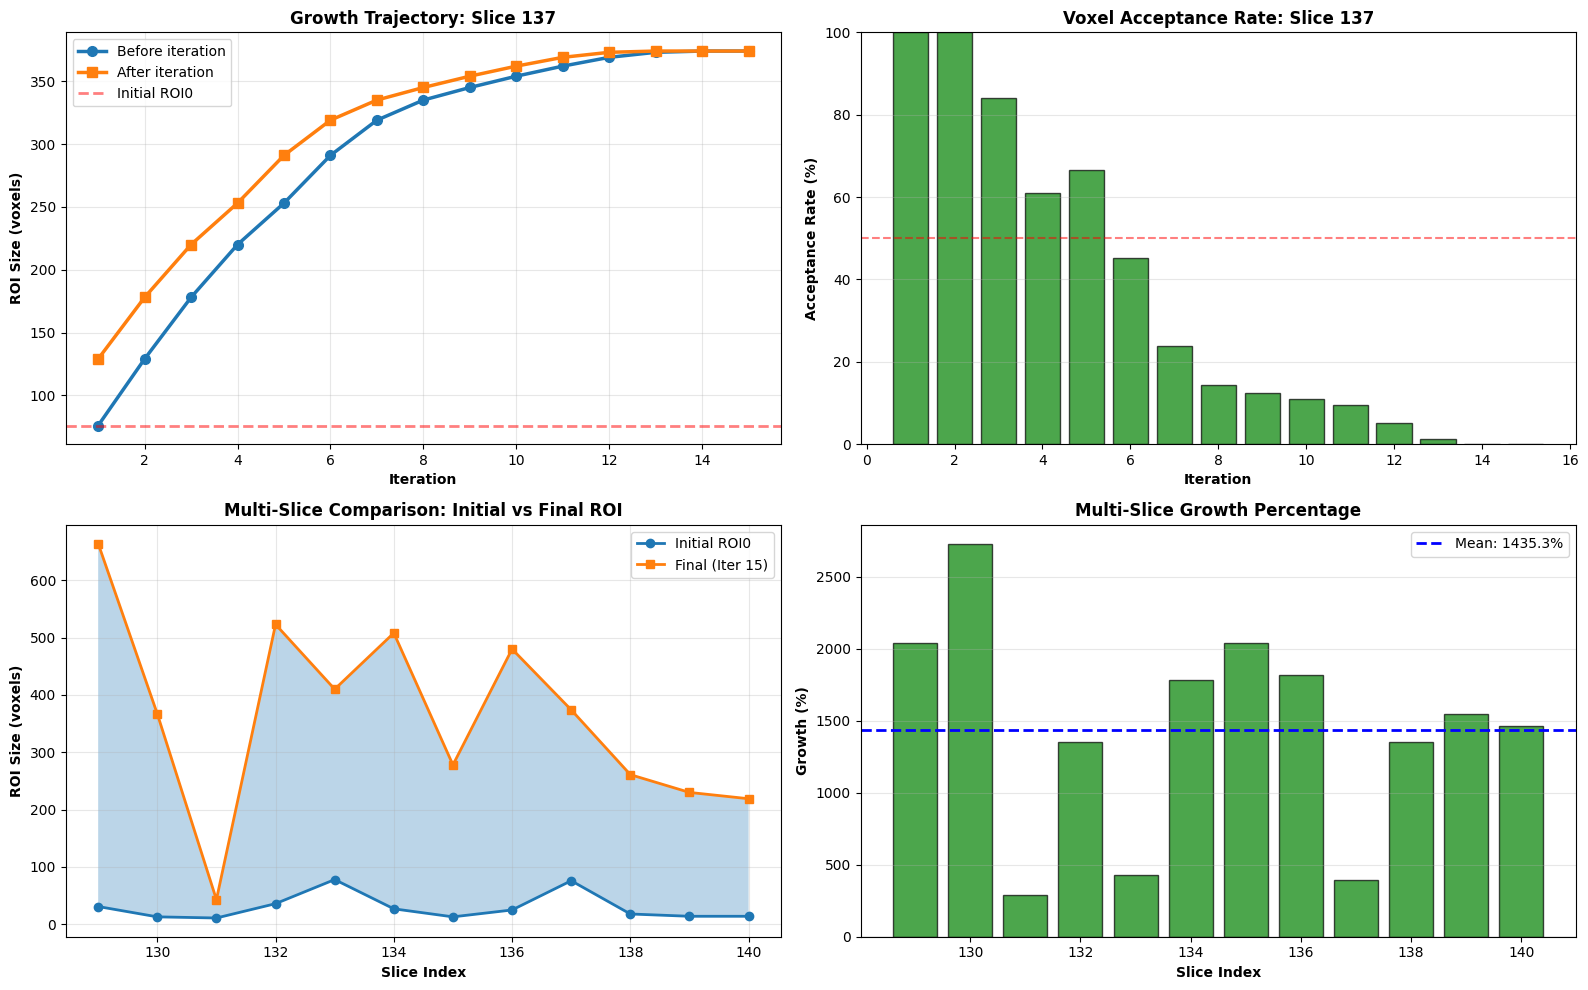


Multi-Slice Statistics:
  - Slices with positive growth: 12/12
  - Mean growth per slice: 333 voxels
  - Median growth per slice: 315 voxels
  - Mean growth percentage: 1435.3%


In [79]:
# ==============================================================================
# 6C. GROWTH TRAJECTORIES & MULTI-SLICE COMPARISON
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Growth trajectory for a specific slice
slice_for_trajectory = slice_to_show
results_slice = multi_slice_data[slice_for_trajectory]['results']
iter_range = results_slice['Iteration'].values
roi_sizes = results_slice['Current ROI Size'].values
new_sizes = results_slice['New ROI Size'].values

axes[0, 0].plot(iter_range, roi_sizes, 'o-', linewidth=2.5, markersize=7, label='Before iteration')
axes[0, 0].plot(iter_range, new_sizes, 's-', linewidth=2.5, markersize=7, label='After iteration')
axes[0, 0].axhline(multi_slice_data[slice_for_trajectory]['mask0'].sum(), 
                   color='r', linestyle='--', alpha=0.5, linewidth=2, label='Initial ROI0')
axes[0, 0].set_xlabel("Iteration", fontweight='bold')
axes[0, 0].set_ylabel("ROI Size (voxels)", fontweight='bold')
axes[0, 0].set_title(f"Growth Trajectory: Slice {slice_for_trajectory}", fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(alpha=0.3)

# Plot 2: Acceptance rates across iterations
n_accepted = results_slice['Accepted'].values
n_rejected = results_slice['Rejected'].values
acceptance_rate = (n_accepted / (n_accepted + n_rejected)) * 100

axes[0, 1].bar(iter_range, acceptance_rate, alpha=0.7, color='green', edgecolor='k')
axes[0, 1].axhline(50, color='r', linestyle='--', linewidth=1.5, alpha=0.5)
axes[0, 1].set_xlabel("Iteration", fontweight='bold')
axes[0, 1].set_ylabel("Acceptance Rate (%)", fontweight='bold')
axes[0, 1].set_title(f"Voxel Acceptance Rate: Slice {slice_for_trajectory}", fontweight='bold')
axes[0, 1].set_ylim([0, 100])
axes[0, 1].grid(alpha=0.3, axis='y')

# Plot 3: Multi-slice comparison - Final ROI sizes
final_sizes = [multi_slice_data[s]['roi_final'].sum() for s in SLICE_RANGE]
initial_sizes = [multi_slice_data[s]['mask0'].sum() for s in SLICE_RANGE]
slices_list = list(SLICE_RANGE)

axes[1, 0].plot(slices_list, initial_sizes, 'o-', linewidth=2, markersize=6, label='Initial ROI0')
axes[1, 0].plot(slices_list, final_sizes, 's-', linewidth=2, markersize=6, label=f'Final (Iter {NUM_ITERATIONS})')
axes[1, 0].fill_between(slices_list, initial_sizes, final_sizes, alpha=0.3)
axes[1, 0].set_xlabel("Slice Index", fontweight='bold')
axes[1, 0].set_ylabel("ROI Size (voxels)", fontweight='bold')
axes[1, 0].set_title("Multi-Slice Comparison: Initial vs Final ROI", fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(alpha=0.3)

# Plot 4: Growth statistics across slices
growth_amounts = [final_sizes[i] - initial_sizes[i] for i in range(len(slices_list))]
growth_percents = [(g / initial_sizes[i]) * 100 for i, g in enumerate(growth_amounts)]

color_map = ['green' if g > 0 else 'red' for g in growth_amounts]
axes[1, 1].bar(slices_list, growth_percents, alpha=0.7, color=color_map, edgecolor='k')
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].axhline(np.mean(growth_percents), color='blue', linestyle='--', linewidth=2, 
                   label=f'Mean: {np.mean(growth_percents):.1f}%')
axes[1, 1].set_xlabel("Slice Index", fontweight='bold')
axes[1, 1].set_ylabel("Growth (%)", fontweight='bold')
axes[1, 1].set_title("Multi-Slice Growth Percentage", fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nMulti-Slice Statistics:")
print(f"  - Slices with positive growth: {sum(1 for g in growth_amounts if g > 0)}/{len(slices_list)}")
print(f"  - Mean growth per slice: {np.mean(growth_amounts):.0f} voxels")
print(f"  - Median growth per slice: {np.median(growth_amounts):.0f} voxels")
print(f"  - Mean growth percentage: {np.mean(growth_percents):.1f}%")

In [80]:
# ==============================================================================
# 7. MULTI-SLICE EXPORT & SUMMARY
# ==============================================================================

output_dir = Path("results")
output_dir.mkdir(exist_ok=True)

# Export results for each slice
print("Exporting results...\n")

for slice_idx in SLICE_RANGE:
    slice_results = multi_slice_data[slice_idx]['results']
    csv_file = output_dir / f"iteration_results_slice_{slice_idx:03d}.csv"
    slice_results.to_csv(csv_file, index=False)
    print(f"✓ Exported: {csv_file}")

# Combine all slice results into single summary
combined_results = []
for slice_idx in SLICE_RANGE:
    slice_results = multi_slice_data[slice_idx]['results'].copy()
    slice_results.insert(0, 'Slice', slice_idx)
    combined_results.append(slice_results)

df_combined = pd.concat(combined_results, ignore_index=True)
combined_csv = output_dir / "combined_results_all_slices.csv"
df_combined.to_csv(combined_csv, index=False)
print(f"\n✓ Combined results exported: {combined_csv}")

# Create comprehensive summary
summary_text = f"""
================================================================================
MULTI-SLICE ITERATIVE RADIOMICS-GUIDED REGION GROWING - EXECUTION SUMMARY
================================================================================

PARAMETERS:
  - Slice range: {START_SLICE} to {END_SLICE} ({len(SLICE_RANGE)} slices)
  - ROI crop offset (fixed for all slices): {ROI_CROP}
  - Initial threshold: {THRESHOLD_PERCENTILE * 100:.0f}% of max
  - Radiomic feature: {FEATURE_CLASS}.{FEATURE_NAME}
  - K-value (acceptance bounds): {K_VALUE}
  - Number of iterations per slice: {NUM_ITERATIONS}

PROCESSING RESULTS BY SLICE:
"""

for slice_idx in SLICE_RANGE:
    mask0 = multi_slice_data[slice_idx]['mask0']
    roi_final = multi_slice_data[slice_idx]['roi_final']
    mean_ref = multi_slice_data[slice_idx]['mean_ref']
    std_ref = multi_slice_data[slice_idx]['std_ref']
    
    total_growth = roi_final.sum() - mask0.sum()
    percent_growth = (total_growth / mask0.sum()) * 100
    
    summary_text += f"""
  Slice {slice_idx:3d}:
    - Initial ROI0 size: {mask0.sum():5d} voxels
    - Final ROI size:    {roi_final.sum():5d} voxels
    - Voxels added:      {total_growth:5d} voxels ({percent_growth:6.1f}%)
    - Reference mean:    {mean_ref:10.4f}
    - Reference std:     {std_ref:10.4f}
"""

total_initial = sum(multi_slice_data[s]['mask0'].sum() for s in SLICE_RANGE)
total_final = sum(multi_slice_data[s]['roi_final'].sum() for s in SLICE_RANGE)
total_added = total_final - total_initial

summary_text += f"""
OVERALL STATISTICS:
  - Total slices processed: {len(SLICE_RANGE)}
  - Total initial voxels (all ROI0s): {total_initial}
  - Total final voxels (all final ROIs): {total_final}
  - Total voxels added: {total_added}
  - Mean growth per slice: {total_added / len(SLICE_RANGE):.0f} voxels
  - Mean growth percentage: {(total_added / total_initial) * 100:.1f}%

FILES EXPORTED:
  - Individual slice results: iteration_results_slice_XXXX.csv
  - Combined results: combined_results_all_slices.csv
  - Summary: execution_summary.txt

================================================================================
"""

summary_file = output_dir / "execution_summary.txt"
with open(summary_file, 'w') as f:
    f.write(summary_text)

print(f"\n✓ Summary exported: {summary_file}")
print("\n" + summary_text)

Exporting results...

✓ Exported: results\iteration_results_slice_129.csv
✓ Exported: results\iteration_results_slice_130.csv
✓ Exported: results\iteration_results_slice_131.csv
✓ Exported: results\iteration_results_slice_132.csv
✓ Exported: results\iteration_results_slice_133.csv
✓ Exported: results\iteration_results_slice_134.csv
✓ Exported: results\iteration_results_slice_135.csv
✓ Exported: results\iteration_results_slice_136.csv
✓ Exported: results\iteration_results_slice_137.csv
✓ Exported: results\iteration_results_slice_138.csv
✓ Exported: results\iteration_results_slice_139.csv
✓ Exported: results\iteration_results_slice_140.csv

✓ Combined results exported: results\combined_results_all_slices.csv

✓ Summary exported: results\execution_summary.txt


MULTI-SLICE ITERATIVE RADIOMICS-GUIDED REGION GROWING - EXECUTION SUMMARY

PARAMETERS:
  - Slice range: 129 to 140 (12 slices)
  - ROI crop offset (fixed for all slices): (220, 140)
  - Initial threshold: 65% of max
  - Radiomic fe